In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [72]:
df=pd.read_csv("student_decision_tree.csv")
df.head()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
0,101,2,60,55,50,65,0
1,102,3,65,58,55,70,0
2,103,4,70,60,60,72,0
3,104,5,75,68,65,75,1
4,105,6,80,72,70,80,1


In [73]:
df.describe()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,115.500000,4.466667,72.500000,65.666667,63.000000,73.166667,0.566667
std,8.803408,2.129163,12.851271,12.507469,12.752282,10.248914,0.504007
min,101.000000,1.000000,48.000000,40.000000,38.000000,50.000000,0.000000
25%,108.250000,3.000000,62.250000,55.500000,52.500000,66.500000,0.000000
50%,115.500000,4.500000,73.500000,66.500000,64.000000,74.500000,1.000000
75%,122.750000,6.000000,81.750000,74.750000,71.750000,80.000000,1.000000
max,130.000000,8.000000,94.000000,88.000000,86.000000,91.000000,1.000000


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Student_ID      30 non-null     int64
 1   Study_Hours     30 non-null     int64
 2   Attendance      30 non-null     int64
 3   Assignments     30 non-null     int64
 4   Previous_Marks  30 non-null     int64
 5   Discipline      30 non-null     int64
 6   Pass            30 non-null     int64
dtypes: int64(7)
memory usage: 1.8 KB


In [75]:
df.shape

(30, 7)

In [76]:
df.isnull().sum()

Student_ID        0
Study_Hours       0
Attendance        0
Assignments       0
Previous_Marks    0
Discipline        0
Pass              0
dtype: int64

In [77]:
df.corr()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
Student_ID,1.000000,0.088305,0.107440,0.126521,0.121328,0.093062,0.167091
Study_Hours,0.088305,1.000000,0.988014,0.981074,0.988064,0.972884,0.837611
Attendance,0.107440,0.988014,1.000000,0.996274,0.997768,0.989492,0.849142
Assignments,0.126521,0.981074,0.996274,1.000000,0.997305,0.989836,0.846044
Previous_Marks,0.121328,0.988064,0.997768,0.997305,1.000000,0.990973,0.842320
Discipline,0.093062,0.972884,0.989492,0.989836,0.990973,1.000000,0.822206
Pass,0.167091,0.837611,0.849142,0.846044,0.842320,0.822206,1.000000


In [78]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Attendance', 'Assignments',
       'Previous_Marks', 'Discipline', 'Pass'],
      dtype='object')

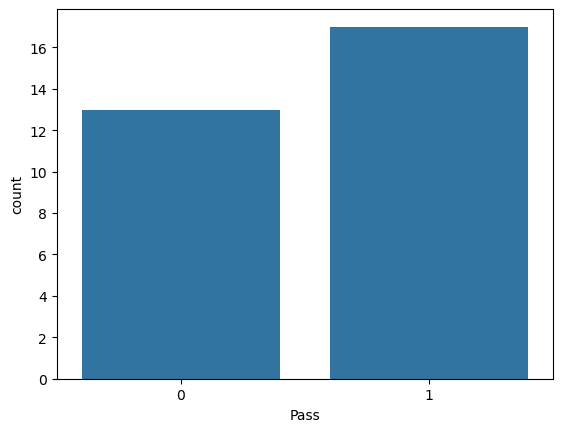

In [79]:
sns.countplot(x="Pass",data=df)
plt.show()

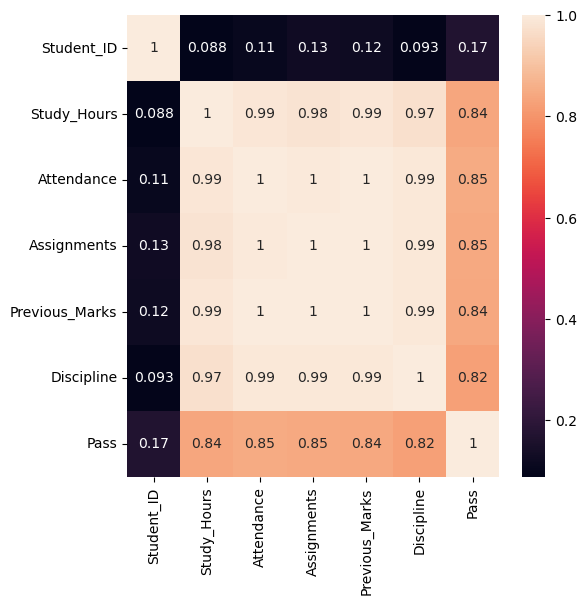

In [80]:
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [81]:
x=df.drop(["Student_ID","Pass"],axis=1)
y=df["Pass"]
x

,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline
0,2,60,55,50,65
1,3,65,58,55,70
2,4,70,60,60,72
3,5,75,68,65,75
4,6,80,72,70,80
5,7,85,78,75,82
6,8,90,82,80,85
7,2,55,50,48,60
8,3,68,62,58,68
9,4,72,65,63,74


In [82]:
x_train, x_test, y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape

(24, 5)

In [83]:
x_test.shape

(6, 5)

In [84]:
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [85]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 1])

In [86]:
accuracy_score(y_test,y_pred)

0.8333333333333334

In [87]:
confusion_matrix(y_test,y_pred)

array([[2, 0],
       [1, 3]])

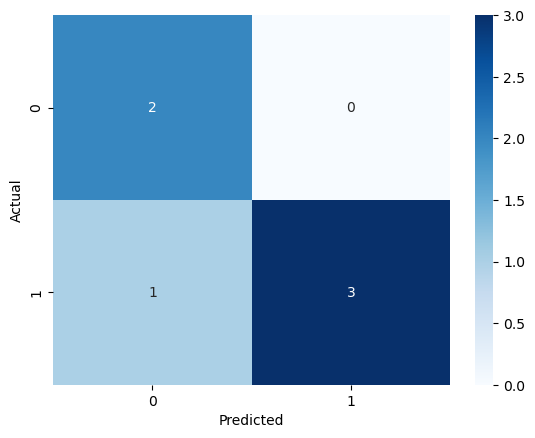

In [88]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [89]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



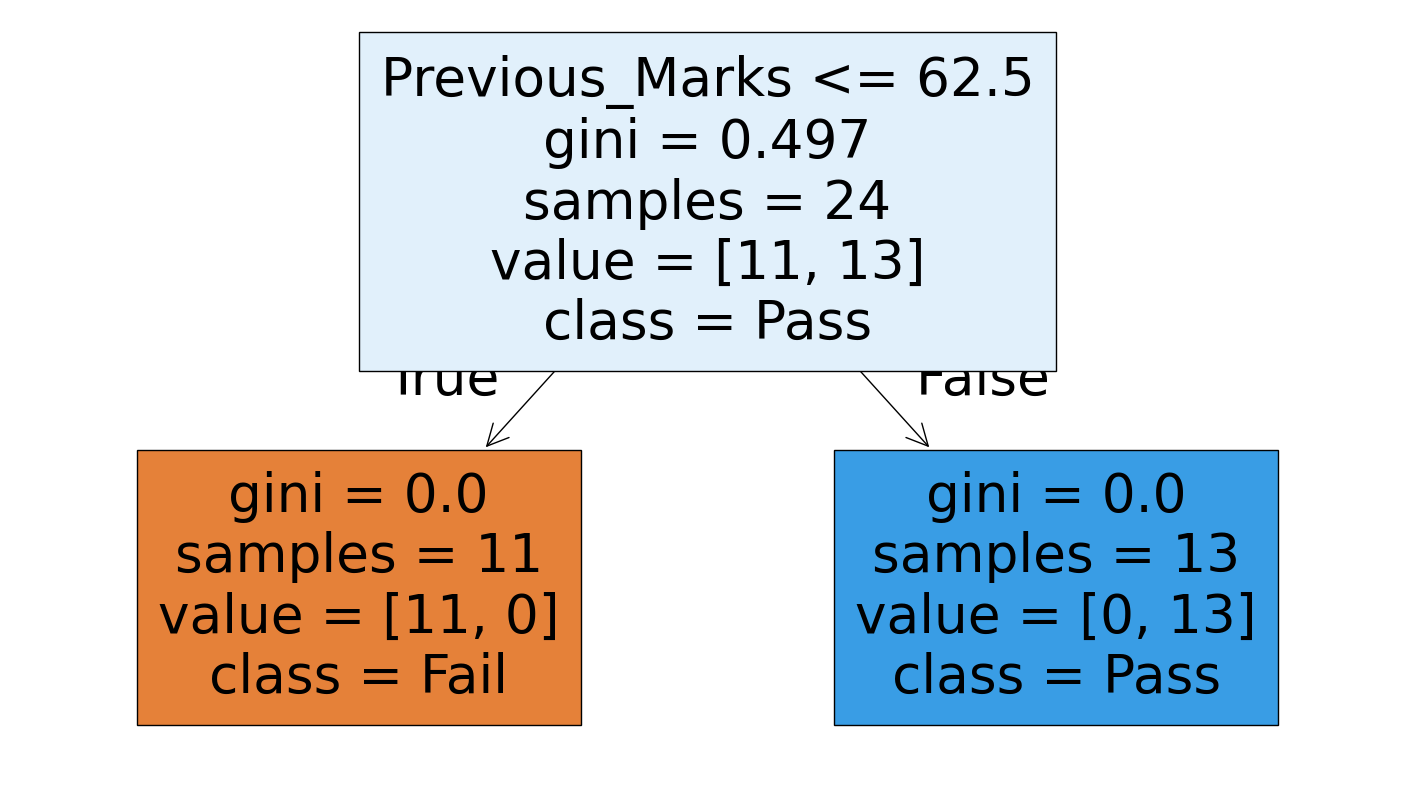

In [90]:

plt.figure(figsize=(18,10))
plot_tree(model, feature_names=x.columns, class_names=["Fail", "Pass"], filled=True)
plt.show()


In [91]:
importance= pd.DataFrame({"Feature":x.columns,"Importance":model.feature_importances_})
importance.sort_values(by= "Importance",ascending=False)

,Feature,Importance
3,Previous_Marks,1.0
0,Study_Hours,0.0
1,Attendance,0.0
2,Assignments,0.0
4,Discipline,0.0


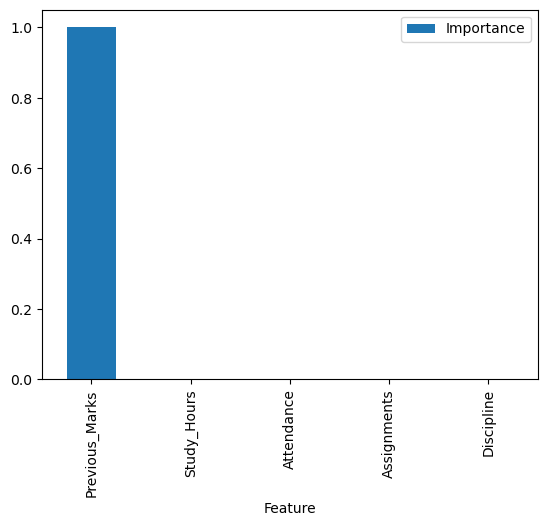

In [92]:
importance.sort_values(by="Importance", ascending=False).plot(x="Feature", y="Importance", kind="bar")
plt.show()

In [93]:
new_student=[
    [2,55,58,45,60],
    [6,82,75,72,80],
    [8,95,88,86,92]
]
pred=model.predict(new_student)
pred

c:\Users\kanan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0, 1, 1])

In [94]:
#random_forest 
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [95]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0])

In [96]:
comparison= pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})
comparison

,Actual,Predicted
27,1,1
15,0,0
23,1,0
17,1,1
8,0,0
9,1,0


In [97]:
confusion_matrix(y_test,y_pred)

array([[2, 0],
       [2, 2]])

In [98]:
accuracy_score(y_test,y_pred)

0.6666666666666666

In [99]:
df=pd.read_csv("student_final_marks_dataset.csv")
df.head()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
0,101,2,65,55,50,54
1,102,3,68,58,55,58
2,103,3,70,60,57,60
3,104,4,72,62,60,63
4,105,4,75,65,62,66


In [100]:
df.isnull().sum()

Student_ID          0
Study_Hours         0
Attendance          0
Assignment_Score    0
Previous_Marks      0
Final_Marks         0
dtype: int64

In [101]:
df.duplicated().sum()

np.int64(0)

In [102]:
df.shape

(20, 6)

In [103]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Attendance', 'Assignment_Score',
       'Previous_Marks', 'Final_Marks'],
      dtype='object')

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Student_ID        20 non-null     int64
 1   Study_Hours       20 non-null     int64
 2   Attendance        20 non-null     int64
 3   Assignment_Score  20 non-null     int64
 4   Previous_Marks    20 non-null     int64
 5   Final_Marks       20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [105]:
df.describe()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
count,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,110.50000,5.950000,81.750000,73.300000,70.900000,75.150000
std,5.91608,2.258901,8.848877,10.533655,11.317895,11.979258
min,101.00000,2.000000,65.000000,55.000000,50.000000,54.000000
25%,105.75000,4.000000,75.750000,65.750000,63.500000,66.750000
50%,110.50000,6.000000,82.500000,72.500000,70.500000,74.500000
75%,115.25000,8.000000,89.250000,82.500000,80.500000,85.500000
max,120.00000,10.000000,95.000000,90.000000,90.000000,95.000000


In [106]:
df.corr(numeric_only=True)

,Student_ID,Study_Hours,Attendance,Assignment_Score,Previous_Marks,Final_Marks
Student_ID,1.000000,0.667552,0.720345,0.698456,0.705081,0.696974
Study_Hours,0.667552,1.000000,0.986740,0.991606,0.994125,0.994186
Attendance,0.720345,0.986740,1.000000,0.995760,0.994554,0.995379
Assignment_Score,0.698456,0.991606,0.995760,1.000000,0.997988,0.999407
Previous_Marks,0.705081,0.994125,0.994554,0.997988,1.000000,0.999332
Final_Marks,0.696974,0.994186,0.995379,0.999407,0.999332,1.000000


<Axes: >

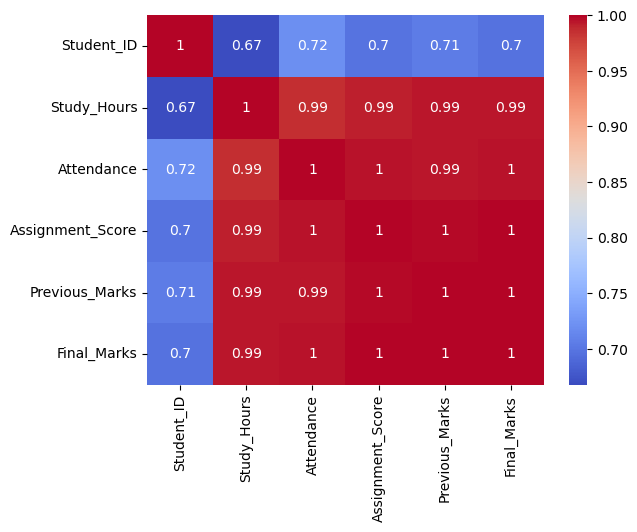

In [107]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

<Axes: xlabel='Study_Hours', ylabel='Count'>

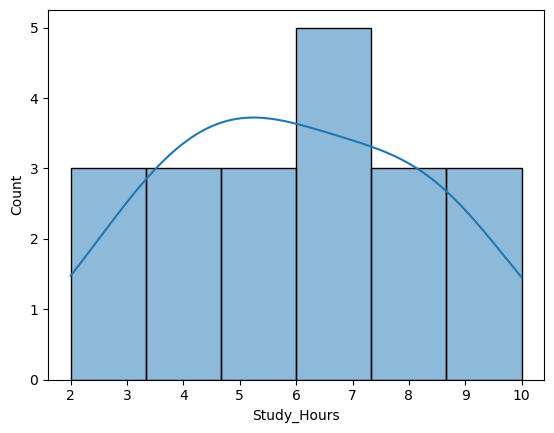

In [108]:
sns.histplot(df["Study_Hours"],kde=True)
             

<Axes: xlabel='Attendance'>

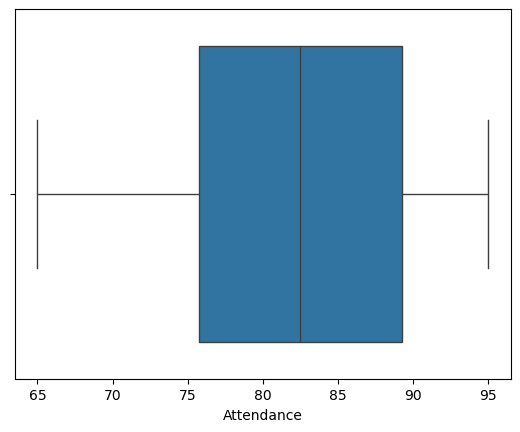

In [109]:
sns.boxplot(x=df["Attendance"])

In [110]:
x = df.drop(["Student_ID", "Final_Marks"], axis=1)
y = df["Final_Marks"]


In [111]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape

(16, 4)

In [112]:
x_test.shape

(4, 4)

In [113]:
model=RandomForestClassifier()
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [114]:
y_pred=model.predict(x_test)

In [115]:
y_pred

array([60, 74, 92, 60])

In [116]:
comparison=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comparison

,Actual,Predicted
0,54,60
17,75,74
15,95,92
1,58,60


In [117]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.0

In [119]:
df=pd.read_csv("student_marks_dataset.csv")
df.head()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Final_Marks
0,101,2,70,60,58,55
1,102,3,75,65,62,60
2,103,4,80,70,68,66
3,104,5,85,75,72,73
4,105,6,88,78,75,77


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Student_ID      15 non-null     int64
 1   Study_Hours     15 non-null     int64
 2   Attendance      15 non-null     int64
 3   Assignments     15 non-null     int64
 4   Previous_Marks  15 non-null     int64
 5   Final_Marks     15 non-null     int64
dtypes: int64(6)
memory usage: 852.0 bytes


In [121]:
df.isnull().sum()

Student_ID        0
Study_Hours       0
Attendance        0
Assignments       0
Previous_Marks    0
Final_Marks       0
dtype: int64

In [122]:
df.describe()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Final_Marks
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,108.000000,5.800000,84.933333,76.800000,74.800000,76.600000
std,4.472136,2.366432,8.447034,10.248345,10.857519,13.881128
min,101.000000,2.000000,70.000000,60.000000,58.000000,55.000000
25%,104.500000,4.000000,79.000000,69.000000,66.500000,65.000000
50%,108.000000,6.000000,86.000000,78.000000,75.000000,77.000000
75%,111.500000,7.500000,91.500000,84.500000,83.000000,87.500000
max,115.000000,10.000000,96.000000,92.000000,91.000000,97.000000


In [123]:
x=df.drop(["Student_ID","Final_Marks"],axis=1)
y=df["Final_Marks"]
x


,Study_Hours,Attendance,Assignments,Previous_Marks
0,2,70,60,58
1,3,75,65,62
2,4,80,70,68
3,5,85,75,72
4,6,88,78,75
5,7,90,82,80
6,8,92,85,84
7,9,94,88,88
8,10,96,92,91
9,5,82,73,70


In [124]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape

(12, 4)

In [125]:
model=RandomForestClassifier()
model.fit(x_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [126]:
y_pred=model.predict(x_test)

In [127]:
y_pred

array([73, 77, 58])

In [128]:
accuracy_score(y_test,y_pred)

0.0

In [129]:
data=pd.read_csv("student.csv")
data.head()

,StudentID,Age,StudyTimeWeekly,Absences,GPA,Gender,Ethnicity,ParentalEducation,Tutoring,ParentalSupport,ClubInvolvement,Sports,Music,Volunteering,GradeClass
0,1001,17,19.833723,7,2.929196,Female,Caucasian,Some College,Yes,Moderate,No,No,Yes,No,C
1,1002,18,15.408756,0,3.042915,Male,Caucasian,High School,No,Low,No,No,No,No,B
2,1003,15,4.210570,26,0.112602,Male,Asian,Bachelor's,No,Moderate,No,No,No,No,F
3,1004,17,10.028829,14,2.054218,Female,Caucasian,Bachelor's,No,High,Yes,No,No,No,D
4,1005,17,4.672495,17,1.288061,Female,Caucasian,Some College,Yes,High,No,No,No,No,F


In [130]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6055 entries, 0 to 6054
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          6055 non-null   int64  
 1   Age                6055 non-null   int64  
 2   StudyTimeWeekly    6055 non-null   float64
 3   Absences           6055 non-null   int64  
 4   GPA                6055 non-null   float64
 5   Gender             6055 non-null   object 
 6   Ethnicity          6055 non-null   object 
 7   ParentalEducation  5645 non-null   object 
 8   Tutoring           6055 non-null   object 
 9   ParentalSupport    5755 non-null   object 
 10  ClubInvolvement    6055 non-null   object 
 11  Sports             6055 non-null   object 
 12  Music              6055 non-null   object 
 13  Volunteering       6055 non-null   object 
 14  GradeClass         6055 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 709.7+ KB


In [131]:
data.isnull().sum()

StudentID              0
Age                    0
StudyTimeWeekly        0
Absences               0
GPA                    0
Gender                 0
Ethnicity              0
ParentalEducation    410
Tutoring               0
ParentalSupport      300
ClubInvolvement        0
Sports                 0
Music                  0
Volunteering           0
GradeClass             0
dtype: int64

In [132]:
data.dropna(inplace=True)

In [133]:
data.isnull().sum()

StudentID            0
Age                  0
StudyTimeWeekly      0
Absences             0
GPA                  0
Gender               0
Ethnicity            0
ParentalEducation    0
Tutoring             0
ParentalSupport      0
ClubInvolvement      0
Sports               0
Music                0
Volunteering         0
GradeClass           0
dtype: int64

In [134]:
data.shape

(5366, 15)

In [135]:
data.describe()

,StudentID,Age,StudyTimeWeekly,Absences,GPA
count,5366.000000,5366.000000,5366.000000,5366.000000,5366.000000
mean,4107.965896,16.240589,10.406434,9.606597,2.481171
std,1730.183616,1.027887,5.691587,8.093518,0.895914
min,1001.000000,15.000000,0.001057,0.000000,0.000000
25%,2632.250000,15.000000,5.480358,3.000000,1.992908
50%,4154.500000,16.000000,10.424931,7.000000,2.592364
75%,5582.750000,17.000000,15.357253,15.000000,3.199588
max,7055.000000,18.000000,19.978094,29.000000,4.000000


In [136]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5366 entries, 0 to 6054
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          5366 non-null   int64  
 1   Age                5366 non-null   int64  
 2   StudyTimeWeekly    5366 non-null   float64
 3   Absences           5366 non-null   int64  
 4   GPA                5366 non-null   float64
 5   Gender             5366 non-null   object 
 6   Ethnicity          5366 non-null   object 
 7   ParentalEducation  5366 non-null   object 
 8   Tutoring           5366 non-null   object 
 9   ParentalSupport    5366 non-null   object 
 10  ClubInvolvement    5366 non-null   object 
 11  Sports             5366 non-null   object 
 12  Music              5366 non-null   object 
 13  Volunteering       5366 non-null   object 
 14  GradeClass         5366 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 670.8+ KB


In [142]:
data["GradeClass"]=data["GradeClass"].map({"A":1,"B":2,"C":3,"D":4,"E":5,"F":6})

In [143]:
x = data[["Age", "StudyTimeWeekly", "Absences", "GPA"]]
y = data["GradeClass"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
       

In [144]:
x_train.shape

(4292, 4)

In [145]:
x_test.shape

(1074, 4)

In [146]:
model=RandomForestClassifier()
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [147]:
y_pred=model.predict(x_test)

In [148]:
y_pred

array([4, 3, 6, ..., 3, 1, 2], shape=(1074,))

In [149]:
comparison=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comparison

,Actual,Predicted
5452,4,4
4988,3,3
2521,6,6
1716,6,6
1991,4,4
...,...,...
3888,2,2
1375,1,1
5016,3,3
3433,1,1


In [150]:
accuracy_score(y_test,y_pred)

0.9990689013035382

In [152]:
cm= confusion_matrix(y_test,y_pred)
cm

array([[144,   0,   0,   0,   0],
       [  0, 175,   1,   0,   0],
       [  0,   0, 214,   0,   0],
       [  0,   0,   0, 245,   0],
       [  0,   0,   0,   0, 295]])

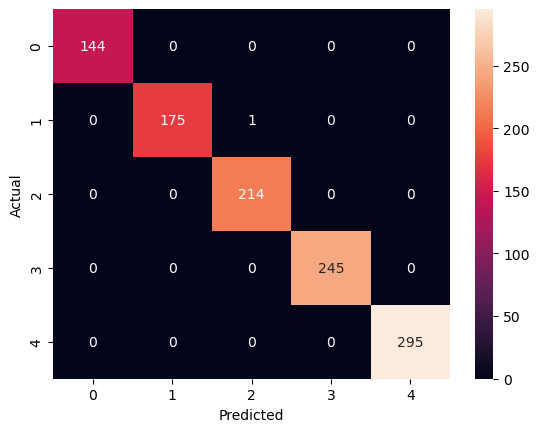

In [153]:
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [154]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       144
           2       1.00      0.99      1.00       176
           3       1.00      1.00      1.00       214
           4       1.00      1.00      1.00       245
           6       1.00      1.00      1.00       295

    accuracy                           1.00      1074
   macro avg       1.00      1.00      1.00      1074
weighted avg       1.00      1.00      1.00      1074



In [155]:
importance=model.feature_importances_
importance

array([0.00227039, 0.02541235, 0.17435481, 0.79796246])

In [158]:
importance=pd.DataFrame({"Feature":x.columns,"Importance":model.feature_importances_})
importance.sort_values(by="Importance",ascending=False)

,Feature,Importance
3,GPA,0.797962
2,Absences,0.174355
1,StudyTimeWeekly,0.025412
0,Age,0.002270


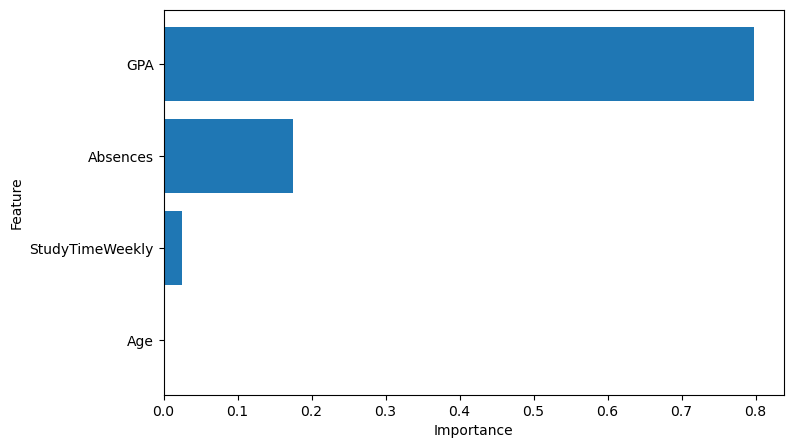

In [159]:
plt.figure(figsize=(8,5))
plt.barh(importance["Feature"],importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [160]:
new_student=[[6.7,10,5,2.5]]
pred=model.predict(new_student)
pred

c:\Users\kanan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([3])

In [161]:
import joblib
joblib.dump(model,"student_grades_model.pkl")


['student_grades_model.pkl']